# Galaxy-Pick — PJ1 Analysis

**Problem.** A shopper walking into a store faces ~37 current Galaxy models and no good way to choose. Spec sheets don't answer *"which one is right for me?"* — that depends on what the shopper actually cares about.

**Approach.** We turn raw specs into four interpretable 0–10 scores (**camera, performance, battery, value**), then rank phones with a **Weighted Sum Model (WSM)**: each shopper persona supplies a weight vector over those four factors, and every phone gets a `match_score`. It is fully deterministic and every recommendation can be explained in one line — no black box.

**Honesty about the data (Ch. 4).** The dataset is *curated*, not scraped, and two different things in it have two different provenances:

- **Specs are confirmed for all 37 models** (`spec_source=real`). Nothing here is a projection. Earlier versions of this catalog carried *modelled* 2026 specs while that line was unreleased; when the real sheets arrived they corrected several rows that had looked perfectly plausible — the S26 runs an **Exynos 2600**, not the invented "Snapdragon 8 Elite Gen2"; the S26 Ultra is **5000 mAh / 60 W**, not 5200 / 65. The projection-disclosure machinery is still in the engine (`spec_source=mock` → a warning on every card and in the reason text); it simply has nothing to flag today.
- **Prices are a mix, and the mix is labelled per row.** `launch_price_inr` is real MSRP everywhere. `price_inr` — the number the shopper sees and that `value_score` divides by — is the **estimated street price in 2026**: real for the 10 models on sale now (`price_source=launch_msrp`), and **modelled by depreciating MSRP by age** for the 27 older models (`price_source=depreciation_model`). That estimate is the least certain input in the whole model, and §8 says so plainly.

Prices are in **INR (₹)**.

> All logic lives in `src/recommender/` and is imported here — the notebook and the Streamlit app run the **same engine**, so they can never disagree.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.recommender import data, explain, personas, scoring, wsm

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (7, 3.5)
plt.rcParams["axes.spines.top"] = plt.rcParams["axes.spines.right"] = False

SAMSUNG_BLUE = "#1428A0"
print("engine imported from", ROOT / "src" / "recommender")

engine imported from /Users/nikhil/Documents/Galaxy-Pick/src/recommender


## 1. Load the catalog

`data.load_phones()` reads `data/processed/phones.csv` **and validates it** — the row contract (2024–2026 only, every 2026 row flagged `mock`, all scores within [0,10], no nulls in required columns) is enforced on load, so a broken dataset fails loudly here rather than silently skewing a recommendation.

In [2]:
df = data.load_phones()

print("shape:", df.shape)
print("provenance:", data.provenance(df))
df.head()

shape: (37, 21)
provenance: {'total': 37, 'real': 37, 'mock': 0, 'mock_years': [], 'modelled_prices': 27}


,model_name,series,launch_year,launch_price_inr,ram_gb,storage_gb,chipset,rear_camera_mp,battery_mah,screen_size_inch,refresh_rate_hz,charging_w,segment,spec_source,price_inr,price_source,camera_score,performance_score,battery_score,value_score,image_ref
0,Galaxy S24,S,2024,87559,8,256,Exynos 2400,50,4000,6.2,120,25,business,real,40500,depreciation_model,7.8,7.9,5.6,1.9,placeholder:S:Galaxy S24
1,Galaxy S24+,S,2024,107559,8,256,Exynos 2400,50,4900,6.7,120,45,business,real,49700,depreciation_model,7.8,7.9,7.9,1.6,placeholder:S:Galaxy S24+
2,Galaxy S24 Ultra,S-Ultra,2024,147559,12,256,Snapdragon 8 Gen3,200,5000,6.8,120,45,photography,real,68200,depreciation_model,9.6,8.9,8.1,1.1,placeholder:S-Ultra:Galaxy S24 Ultra
3,Galaxy S24 FE,S-FE,2024,67559,8,256,Exynos 2400e,50,4700,6.7,120,25,gaming,real,31200,depreciation_model,7.0,7.5,7.0,2.8,placeholder:S-FE:Galaxy S24 FE
4,Galaxy Z Flip6,Z-Flip,2024,117559,8,256,Snapdragon 8 Gen3,50,4000,6.7,120,25,business,real,54400,depreciation_model,6.8,8.5,5.6,1.1,placeholder:Z-Flip:Galaxy Z Flip6


In [3]:
df.describe().round(1)

,launch_year,launch_price_inr,ram_gb,storage_gb,rear_camera_mp,battery_mah,screen_size_inch,refresh_rate_hz,charging_w,price_inr,camera_score,performance_score,battery_score,value_score
count,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0,37.0
mean,2024.9,59746.1,7.7,174.7,66.2,5000.0,6.7,111.9,32.4,41483.0,6.5,6.2,7.7,3.7
std,0.8,53150.4,2.2,65.1,47.2,543.1,0.3,13.5,10.5,36479.7,1.5,2.3,1.1,3.0
min,2024.0,9999.0,4.0,64.0,50.0,4000.0,6.2,90.0,25.0,9000.0,4.8,3.3,5.6,0.0
25%,2024.0,18999.0,6.0,128.0,50.0,4900.0,6.6,90.0,25.0,13700.0,5.2,4.2,7.5,1.1
50%,2025.0,27999.0,8.0,128.0,50.0,5000.0,6.7,120.0,25.0,23800.0,5.8,5.8,7.5,3.5
75%,2026.0,107559.0,8.0,256.0,50.0,5000.0,6.7,120.0,45.0,60200.0,7.8,8.5,8.1,5.9
max,2026.0,182559.0,12.0,256.0,200.0,6000.0,8.0,120.0,60.0,139999.0,10.0,10.0,10.0,10.0


## 2. Exploratory data analysis — three findings

Each finding below is backed by a number and a chart, and each one **changed a downstream design decision**.

### Finding 1 — the segments don't overlap on price, and "photography" is a luxury tier

Samsung's marketing segments map onto cleanly separated price bands, with one striking gap: the cheapest phone in the `photography` segment costs **₹68,200**, while the entire `budget` segment tops out at **₹20,990**. Nothing bridges the ~4× gap between them. There is no such thing as an affordable "photography" phone in this catalog.

**Why it matters:** a persona who wants a great camera on a modest budget cannot be served the *marketing* answer. The recommender has to rank on measured capability within their budget instead — which is exactly what the WSM does.

**Ageing the prices moves the floor but does not close the gap.** At launch MSRP the photography segment started at ₹1,39,999; at 2026 street prices it starts at ₹68,200 — that cheapest entry is a two-year-old S24 Ultra at roughly half its ₹1,47,559 launch price. Depreciation makes the tier *reachable* (it is why an ₹80,000 photography budget can now buy an Ultra at all — see §7), but a budget shopper still cannot cross it.

,min,median,max,count
segment,,,,
budget,9000,12800.0,20990,13
gaming,19500,23800.0,31200,5
business,17300,52050.0,124100,16
photography,68200,100300.0,139999,3


photography segment starts at ₹68,200
budget segment tops out at    ₹20,990
→ gap between the two bands:  ₹47,210


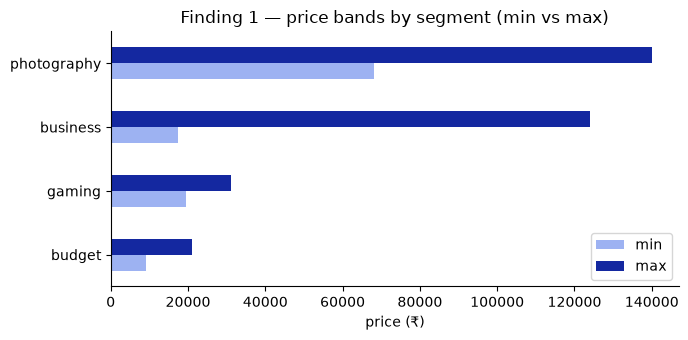

In [4]:
price_by_segment = df.groupby("segment")["price_inr"].agg(["min", "median", "max", "count"]).sort_values("median")
display(price_by_segment)

print(f"photography segment starts at ₹{df[df.segment=='photography'].price_inr.min():,}")
print(f"budget segment tops out at    ₹{df[df.segment=='budget'].price_inr.max():,}")
print(f"→ gap between the two bands:  ₹{df[df.segment=='photography'].price_inr.min() - df[df.segment=='budget'].price_inr.max():,}")

ax = price_by_segment[["min", "max"]].plot(kind="barh", color=["#9DB2F2", SAMSUNG_BLUE])
ax.set_xlabel("price (₹)")
ax.set_ylabel("")
ax.set_title("Finding 1 — price bands by segment (min vs max)")
plt.tight_layout(); plt.show()

### Finding 2 — the surprise: cheap phones have the *biggest* batteries

Price buys almost everything in a phone — except battery capacity, where the relationship **inverts**. The `budget` segment averages the largest cells in the catalog, comfortably beating `business` phones that cost up to 10× more. Budget M/F models ship 6000 mAh; flagships hover near 4000–5000 mAh because they are thinner and spend their cost budget on silicon, optics and displays.

**Why it matters:** battery is the one factor where a budget-conscious persona is not compromising at all. It's also why `battery_score` and `value_score` reinforce each other for the student persona — and why our EDA needed to check for exactly this kind of correlation rather than assume "expensive = better on every axis".

segment
budget         5385.0
gaming         5140.0
photography    5000.0
business       4644.0
Name: battery_mah, dtype: float64

correlation(price, battery_mah) = -0.46   ← negative: paying more buys LESS battery
budget avg   5,385 mAh
business avg 4,644 mAh


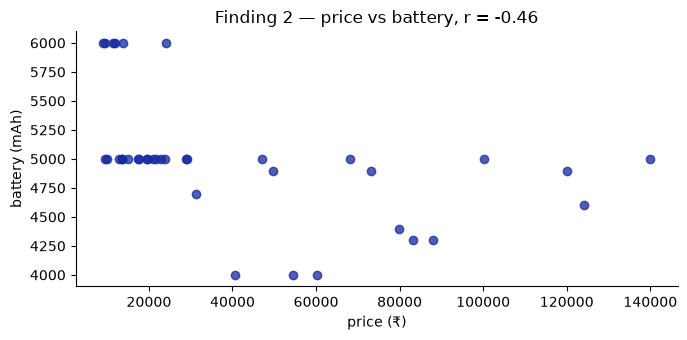

In [5]:
battery_by_segment = df.groupby("segment")["battery_mah"].mean().sort_values(ascending=False)
display(battery_by_segment.round(0))

corr = df["price_inr"].corr(df["battery_mah"])
print(f"correlation(price, battery_mah) = {corr:+.2f}   ← negative: paying more buys LESS battery")
print(f"budget avg   {df[df.segment=='budget'].battery_mah.mean():,.0f} mAh")
print(f"business avg {df[df.segment=='business'].battery_mah.mean():,.0f} mAh")

fig, ax = plt.subplots()
ax.scatter(df["price_inr"], df["battery_mah"], color=SAMSUNG_BLUE, alpha=0.75)
ax.set_xlabel("price (₹)"); ax.set_ylabel("battery (mAh)")
ax.set_title(f"Finding 2 — price vs battery, r = {corr:+.2f}")
plt.tight_layout(); plt.show()

### Finding 3 — megapixels are useless as a camera signal here

`rear_camera_mp` takes **only two distinct values across all 37 phones**: 50 and 200. 33 of 37 are 50MP — and every 200MP phone is a flagship costing ≥ ₹68,200. So megapixel count carries almost no information: it says a ₹9,000 Galaxy F15 and a ₹40,500 Galaxy S24 have *the same camera*, and across the entire sub-₹68,000 range it cannot tell any two phones apart at all.

**Why it matters — this finding changed the model.** Our first `camera_score` scored mostly on megapixels. The result was a WSM that rated the **cheapest phone in the catalog as the best photography phone**, because a criterion that never varies cannot influence a ranking, so `value_score` decided every persona by default. We rebuilt `camera_score` around the **series optics tier** (sensor size, OIS, zoom, ISP — the things that actually differ, and which track the series) with megapixels demoted to a small bonus. See §4.

**The same trap, one level up.** The optics tier alone still could not separate an S24 Ultra from an S26 Ultra: same tier, same 200MP, so identical scores two years apart — and `performance_score` was worse, because the chipset tiers overflowed 10.0 and got flattened, giving a 2024 Snapdragon 8 Gen3 and a 2026 8 Elite Gen2 the same 10.0. A criterion that cannot discriminate does not just lose influence — it hands the decision to whatever tie-break happens to run, which was CSV row order. `camera_score` now carries a per-generation term, the tier tables are sized never to clamp, and ties resolve to the newer, then cheaper phone.

In [6]:
print("distinct rear_camera_mp values across the whole catalog:", sorted(df["rear_camera_mp"].unique()))
display(df["rear_camera_mp"].value_counts().rename("phones"))
print(f"cheapest 200MP phone: ₹{df[df.rear_camera_mp==200].price_inr.min():,}")
print(f"phones under ₹80,000 that are NOT 50MP: {(df[df.price_inr<=80000].rear_camera_mp != 50).sum()}  ← none")

# How much does each raw spec actually vary between segments? (coefficient of variation
# of the segment means — higher = more discriminating)
specs = ["price_inr", "rear_camera_mp", "charging_w", "ram_gb", "refresh_rate_hz", "battery_mah", "screen_size_inch"]
spread = pd.Series({c: df.groupby("segment")[c].mean().std() / df.groupby("segment")[c].mean().mean() for c in specs})
spread = spread.sort_values(ascending=False).rename("between-segment variation (CV)")
display(spread.round(3))
print("→ screen size and battery barely vary between segments; price and MP vary most.")

distinct rear_camera_mp values across the whole catalog: [np.int64(50), np.int64(200)]


rear_camera_mp
50     33
200     4
Name: phones, dtype: int64

cheapest 200MP phone: ₹68,200
phones under ₹80,000 that are NOT 50MP: 1  ← none


rear_camera_mp      0.819
price_inr           0.819
ram_gb              0.306
charging_w          0.291
refresh_rate_hz     0.101
battery_mah         0.061
screen_size_inch    0.015
Name: between-segment variation (CV), dtype: float64

→ screen size and battery barely vary between segments; price and MP vary most.


## 3. Feature engineering — raw specs → four 0–10 scores

We import `scoring.py` rather than re-implementing it, so the notebook, the tests and the app are provably scoring phones the same way.

The scores are **transparent heuristics, not benchmarks**. That is a deliberate trade: we can show a shopper exactly why a phone ranked where it did.

In [7]:
# Step 6 of the brief asks for the LOGIC, not just the numbers.
print(scoring.LOGIC_SUMMARY)

camera_score:      series optics tier (Ultra 8.6 → S 7.6 → Fold 7.2 → FE 6.8 → Flip 6.6
                   → A 5.4 → M 4.8 → F 4.6), + a megapixel bonus (50→+0.2, 200→+1.0),
                   + 0.2 per generation since 2024. Optics leads because MP ≠ image
                   quality: sensor size, OIS, zoom and ISP are what differ, and they track
                   the series. The generation term is what separates an S24 Ultra from an
                   S26 Ultra — identical on paper, two sensor generations apart.
performance_score: chipset tier (8 Elite Gen2 9.1 → 8 Elite 8.9 → 8 Gen3 8.6 → … → Dimensity
                   6100+ 3.5) + RAM adjustment (6/8/12 GB → −0.3/0/+0.6) + 0.3 for 120 Hz.
                   Tiers are sized so tier+bonuses reach exactly 10.0 and never clamp: an
                   earlier table let flagships exceed 10 and get flattened to a single
                   value, hiding four chipset generations behind one score.
battery_score:     capacity scaled 3700→600

In [8]:
# Re-derive the scores from raw specs to prove phones.csv is reproducible from the seed.
# The seed stores launch MSRP, so the price must be aged to CATALOG_YEAR first — value_score
# is computed against what a shopper pays today, not what the phone cost at launch.
seed = pd.read_csv(ROOT / "data/raw/curated_seed.csv").rename(columns={"price_inr": "launch_price_inr"})

rebuilt = seed.assign(
    price_inr=[scoring.current_price_inr(p, y, s)
               for p, y, s in zip(seed.launch_price_inr, seed.launch_year, seed.series)],
    camera_score=[scoring.camera_score(mp, s, y)
                  for mp, s, y in zip(seed.rear_camera_mp, seed.series, seed.launch_year)],
    performance_score=[scoring.performance_score(c, r, hz)
                       for c, r, hz in zip(seed.chipset, seed.ram_gb, seed.refresh_rate_hz)],
    battery_score=[scoring.battery_score(b, w, sc)
                   for b, w, sc in zip(seed.battery_mah, seed.charging_w, seed.screen_size_inch)],
)
rebuilt["value_score"] = scoring.value_score_column(rebuilt)

matches = all((rebuilt[c].values == df[c].values).all() for c in wsm.SCORE_COLS)
print("re-derived scores identical to phones.csv:", matches)
print("re-derived prices identical to phones.csv:", (rebuilt.price_inr.values == df.price_inr.values).all())

rebuilt.loc[[0, 2, 15], ["model_name", "series", "launch_year", "launch_price_inr", "price_inr"] + wsm.SCORE_COLS]

re-derived scores identical to phones.csv: True
re-derived prices identical to phones.csv: True


,model_name,series,launch_year,launch_price_inr,price_inr,camera_score,performance_score,battery_score,value_score
0,Galaxy S24,S,2024,87559,40500,7.8,7.9,5.6,1.9
2,Galaxy S24 Ultra,S-Ultra,2024,147559,68200,9.6,8.9,8.1,1.1
15,Galaxy M15 5G,M,2024,12999,9400,5.0,3.3,9.5,9.6


In [9]:
# camera_score now separates phones that megapixels alone called identical.
fifty_mp = df[df.rear_camera_mp == 50]
display(fifty_mp.groupby("series")["camera_score"].first().sort_values(ascending=False).rename("camera_score (all 50MP phones)"))

# value_score is emergent — nobody hand-assigned it; it falls out of specs-per-rupee.
display(df.groupby("series")["value_score"].mean().sort_values(ascending=False).round(1).rename("mean value_score"))
print("→ budget F/M dominate value; foldables score ~0. The model discovered the value ladder on its own.")

series
S         7.8
Z-Fold    7.4
S-FE      7.0
Z-Flip    6.8
A         5.6
M         5.0
F         4.8
Name: camera_score (all 50MP phones), dtype: float64

series
F          7.3
M          5.9
A          4.4
S-FE       2.8
S          1.0
Z-Flip     0.8
S-Ultra    0.5
Z-Fold     0.2
Name: mean value_score, dtype: float64

→ budget F/M dominate value; foldables score ~0. The model discovered the value ladder on its own.


## 4. Personas

Four shoppers, each a weight vector over the four factors. The weights *are* the model — change them and the ranking changes.

| Persona | Camera | Performance | Battery | Value | Budget |
|---|---|---|---|---|---|
| **Photography-first** | **0.50** | 0.10 | 0.20 | 0.20 | ₹80,000 |
| **Gaming & performance** | 0.10 | **0.50** | 0.30 | 0.10 | ₹85,000 |
| **Value / essentials** | 0.15 | 0.20 | 0.30 | **0.35** | ₹20,000 |
| **Business / all-rounder** | 0.25 | 0.30 | 0.25 | 0.20 | ₹1,40,000 |

In [10]:
for name, p in personas.PERSONAS.items():
    total = sum(p["weights"].values())
    print(f"{name}\n  {p['story']}\n  weights={p['weights']}  sum={total:.2f}  budget=₹{p['budget_max']:,}")
    assert abs(total - 1.0) < 1e-9, f"{name} weights must sum to 1.0"
print("\n✓ all four weight vectors sum to 1.0 → match_score is guaranteed to land on the same 0–10 scale")

Photography-first
  Shoots daily and prints the results. Optics lead; screen matters; gaming doesn't.
  weights={'camera': 0.5, 'performance': 0.1, 'battery': 0.2, 'value': 0.2}  sum=1.00  budget=₹80,000
Gaming & performance
  Sustained high-refresh play. Raw performance plus the battery to survive a session.
  weights={'camera': 0.1, 'performance': 0.5, 'battery': 0.3, 'value': 0.1}  sum=1.00  budget=₹85,000
Value / essentials
  Tight budget, no compromises on the basics: value for money and all-day battery.
  weights={'camera': 0.15, 'performance': 0.2, 'battery': 0.3, 'value': 0.35}  sum=1.00  budget=₹20,000
Business / all-rounder
  Premium and reliable across the board; strong battery and camera, no weak axis.
  weights={'camera': 0.25, 'performance': 0.3, 'battery': 0.25, 'value': 0.2}  sum=1.00  budget=₹140,000

✓ all four weight vectors sum to 1.0 → match_score is guaranteed to land on the same 0–10 scale


## 5. The Weighted Sum Model

$$\text{match\_score} = \text{camera} \times w_c + \text{performance} \times w_p + \text{battery} \times w_b + \text{value} \times w_v$$

With scores on 0–10 and weights summing to 1, `match_score` is itself on 0–10.

### Worked example — Photography-first
Weights `0.5 / 0.1 / 0.2 / 0.2`, and a phone scoring camera **9**, performance **6**, battery **7**, value **5**:

$$9(0.5) + 6(0.1) + 7(0.2) + 5(0.2) = 4.5 + 0.6 + 1.4 + 1.0 = \mathbf{7.5}$$

In [11]:
example = pd.DataFrame([{"camera_score": 9, "performance_score": 6, "battery_score": 7, "value_score": 5}])
weights = {"camera": 0.5, "performance": 0.1, "battery": 0.2, "value": 0.2}

result = float(wsm.match_scores(example, weights).iloc[0])
print("9×0.5 + 6×0.1 + 7×0.2 + 5×0.2 =", result)
assert result == 7.5

9×0.5 + 6×0.1 + 7×0.2 + 5×0.2 = 7.5


### Where our first WSM was wrong (Ch. 4 — guarding the model)

The formula above is correct but **not sufficient**, and our first version of this notebook shipped a WSM that quietly ignored its own weights.

A criterion's real influence in a weighted sum is **weight × spread**, not weight alone. Our four raw scores did not share a spread: `value_score` is min–max scaled and uses the full 0–10 range, while `camera_score` spanned about 3 points. So value swung the ranking by 2.0 points at a weight of 0.20, while camera swung it by only 1.5 at a weight of 0.50 — **value outvoted camera at 2.5× less weight**, and every persona collapsed onto the cheapest phone in the catalog. the Photography-first and Value / essentials segments got *identical* top-3s.

The fix is standard multi-criteria decision analysis: **normalize the decision matrix** — the alternatives actually being compared — onto a common scale before applying weights. `wsm.normalize_scores()` does this on the in-budget pool, so "weight 0.50" genuinely means "half the decision". Raw scores are still what we *show* the shopper, because "camera 7.4/10" is meaningful while a pool-relative 0.0 is not.

*Lesson for the deck: the arithmetic was never wrong. The **scales** were — and a plausible-looking model was confidently recommending a ₹9,000 phone to a photographer.*

In [12]:
# The imbalance, quantified — this is the bug that normalization removes.
photo = personas.PERSONAS["Photography-first"]["weights"]

diag = pd.DataFrame({
    "weight": [photo[f] for f in wsm.FACTORS],
    "raw spread": [round(df[c].max() - df[c].min(), 1) for c in wsm.SCORE_COLS],
}, index=wsm.FACTORS)
diag["influence BEFORE (weight × spread)"] = (diag["weight"] * diag["raw spread"]).round(2)
diag["influence AFTER (weight × 10)"] = (diag["weight"] * 10).round(2)
display(diag)
print("Before: value (0.20) swings 2.00 but camera (0.50) swings only 1.50 → value wins. After: weights decide.")

,weight,raw spread,influence BEFORE (weight × spread),influence AFTER (weight × 10)
camera,0.5,5.2,2.60,5.0
performance,0.1,6.7,0.67,1.0
battery,0.2,4.4,0.88,2.0
value,0.2,10.0,2.00,2.0


Before: value (0.20) swings 2.00 but camera (0.50) swings only 1.50 → value wins. After: weights decide.


## 6. Recommendations for each persona

`wsm.recommend()` = filter to budget → normalize the pool → weighted sum → rank → top-3.

In [13]:
SHOW = ["model_name", "price_inr", "camera_score", "performance_score", "battery_score", "value_score", "match_score", "spec_source"]

for name, p in personas.PERSONAS.items():
    top3 = wsm.recommend(df, p["weights"], budget_max=p["budget_max"], top_n=3)
    close = explain.is_close_call(top3)

    print("=" * 100)
    print(f"{name}   —   budget ₹{p['budget_max']:,}")
    print(f"{p['story']}")
    print("=" * 100)
    display(top3[SHOW].reset_index(drop=True))
    for i, (_, row) in enumerate(top3.iterrows(), 1):
        print(f"  {i}. {explain.reason(row, p['weights'], persona_label=name, close_call=close and i <= 2)}")
    print()

Photography-first   —   budget ₹80,000
Shoots daily and prints the results. Optics lead; screen matters; gaming doesn't.


,model_name,price_inr,camera_score,performance_score,battery_score,value_score,match_score,spec_source
0,Galaxy S24 Ultra,68200,9.6,8.9,8.1,1.1,7.23,real
1,Galaxy S25+,73100,8.0,9.1,7.9,0.8,5.44,real
2,Galaxy S24+,49700,7.8,7.9,7.9,1.6,5.20,real


  1. Great for Photography-first: strong camera (9.6/10) and battery life (8.1/10), and at ₹68,200 it fits your budget.
  2. Great for Photography-first: strong camera (8.0/10) and battery life (7.9/10), and at ₹73,100 it fits your budget.
  3. Great for Photography-first: strong camera (7.8/10) and battery life (7.9/10), and at ₹49,700 it fits your budget.



Gaming & performance   —   budget ₹85,000
Sustained high-refresh play. Raw performance plus the battery to survive a session.


,model_name,price_inr,camera_score,performance_score,battery_score,value_score,match_score,spec_source
0,Galaxy S24 Ultra,68200,9.6,8.9,8.1,1.1,7.61,real
1,Galaxy S25+,73100,8.0,9.1,7.9,0.8,7.28,real
2,Galaxy S24+,49700,7.8,7.9,7.9,1.6,6.28,real


  1. Great for Gaming & performance: strong performance (8.9/10) and battery life (8.1/10), and at ₹68,200 it fits your budget.
  2. Great for Gaming & performance: strong performance (9.1/10) and battery life (7.9/10), and at ₹73,100 it fits your budget.
  3. Great for Gaming & performance: strong performance (7.9/10) and battery life (7.9/10), and at ₹49,700 it fits your budget.

Value / essentials   —   budget ₹20,000
Tight budget, no compromises on the basics: value for money and all-day battery.


,model_name,price_inr,camera_score,performance_score,battery_score,value_score,match_score,spec_source
0,Galaxy M15 5G,9400,5.0,3.3,9.5,9.6,6.55,real
1,Galaxy F15 5G,9000,4.8,3.3,9.5,10.0,6.50,real
2,Galaxy M35 5G,13700,5.0,5.0,9.5,7.0,6.14,real


  1. Great for Value / essentials: strong value for money (9.6/10) and battery life (9.5/10), and at ₹9,400 it fits your budget. Note: this was a close call with the runner-up — compare both.
  2. Great for Value / essentials: strong value for money (10.0/10) and battery life (9.5/10), and at ₹9,000 it fits your budget. Note: this was a close call with the runner-up — compare both.
  3. Great for Value / essentials: strong battery life (9.5/10) and value for money (7.0/10), and at ₹13,700 it fits your budget.

Business / all-rounder   —   budget ₹140,000
Premium and reliable across the board; strong battery and camera, no weak axis.


,model_name,price_inr,camera_score,performance_score,battery_score,value_score,match_score,spec_source
0,Galaxy S26 Ultra,139999,10.0,10.0,8.1,0.0,6.92,real
1,Galaxy S25 Ultra,100300,9.8,9.5,8.1,0.5,6.70,real
2,Galaxy S24 Ultra,68200,9.6,8.9,8.1,1.1,6.46,real


  1. Great for Business / all-rounder: strong performance (10.0/10) and camera (10.0/10), and at ₹139,999 it fits your budget. Note: this was a close call with the runner-up — compare both.
  2. Great for Business / all-rounder: strong performance (9.5/10) and camera (9.8/10), and at ₹100,300 it fits your budget. Note: this was a close call with the runner-up — compare both.
  3. Great for Business / all-rounder: strong performance (8.9/10) and camera (9.6/10), and at ₹68,200 it fits your budget.



In [14]:
# Sanity check: the personas must actually disagree, and each must win on what it weights.
winners = {name: wsm.recommend(df, p["weights"], budget_max=p["budget_max"], top_n=1).iloc[0]["model_name"]
           for name, p in personas.PERSONAS.items()}
for name, model in winners.items():
    print(f"{model:20s} ← {name}")
print(f"\ndistinct winners: {len(set(winners.values()))} of {len(winners)} personas")

photo_p = personas.PERSONAS["Photography-first"]
best_cam = df[df.price_inr <= photo_p["budget_max"]]["camera_score"].max()
got_cam = wsm.recommend(df, photo_p["weights"], budget_max=photo_p["budget_max"], top_n=1).iloc[0]["camera_score"]
print(f"The Photography-first pick has camera {got_cam}/10; best camera available under ₹80,000 is {best_cam}/10 → {'✓ match' if got_cam == best_cam else '✗ MISMATCH'}")

Galaxy S24 Ultra     ← Photography-first
Galaxy S24 Ultra     ← Gaming & performance
Galaxy M15 5G        ← Value / essentials
Galaxy S26 Ultra     ← Business / all-rounder

distinct winners: 3 of 4 personas


The Photography-first pick has camera 9.6/10; best camera available under ₹80,000 is 9.6/10 → ✓ match


## 7. Free-text requests (the AI layer, offline)

A shopper who isn't one of our four personas can just type what they want. `nlp_parse.parse()` turns free text into the same `{weights, budget_max, form_factor}` contract a persona provides — using Gemini when a key is present, and a deterministic keyword/regex parser otherwise.

**The demo never depends on a network call:** the cells below run on the rule-based path with no key and no connectivity.

In [15]:
from src.recommender import config, nlp_parse

print("GEMINI_ENABLED:", config.GEMINI_ENABLED, "→ using", "Gemini (with fallback)" if config.GEMINI_ENABLED else "the deterministic parser")

for request in ["photography under ₹50k", "gaming phone with big battery below 30k", "a compact flagship", "asdf qwerty"]:
    parsed = nlp_parse.parse(request)
    top3 = wsm.recommend(df, parsed["weights"], budget_max=parsed["budget_max"],
                         form_factor=parsed["form_factor"], top_n=3)
    print("─" * 100)
    print(f'"{request}"')
    print(f"  parsed → weights={parsed['weights']} budget={parsed['budget_max']} form={parsed['form_factor']}")
    print("  top-3 →", ", ".join(f"{r.model_name} (₹{r.price_inr:,})" for r in top3.itertuples()))
print("─" * 100)
print('\nNote: gibberish → neutral 0.25 weights and no crash. "photography under ₹50k" returns the best')
print('cameras that actually exist under ₹50,000 — discounted S-series flagships, not new A-series,')
print('because ageing prices to 2026 brings a 2024 S24+ (₹49,700) inside a ₹50k budget. No 200MP Ultra')
print('appears: the cheapest is ₹68,200, still over budget. The model is honest about what it can offer.')

GEMINI_ENABLED: False → using the deterministic parser
────────────────────────────────────────────────────────────────────────────────────────────────────
"photography under ₹50k"
  parsed → weights={'camera': 0.4231, 'performance': 0.1923, 'battery': 0.1923, 'value': 0.1923} budget=50000 form=any
  top-3 → Galaxy S24+ (₹49,700), Galaxy S24 (₹40,500), Galaxy S24 FE (₹31,200)
────────────────────────────────────────────────────────────────────────────────────────────────────
"gaming phone with big battery below 30k"
  parsed → weights={'camera': 0.1562, 'performance': 0.3438, 'battery': 0.3438, 'value': 0.1562} budget=30000 form=any
  top-3 → Galaxy M47 5G (₹23,999), Galaxy M35 5G (₹13,700), Galaxy A56 5G (₹28,800)
────────────────────────────────────────────────────────────────────────────────────────────────────
"a compact flagship"
  parsed → weights={'camera': 0.1923, 'performance': 0.4231, 'battery': 0.1923, 'value': 0.1923} budget=None form=compact
  top-3 → Galaxy S26 (₹87,999),

## 8. Wrap-up

### The three findings
1. **The segments don't overlap on price, and "photography" is a luxury tier** — the photography segment starts at ₹68,200 while budget caps at ₹20,990, a ~4× gap that depreciation narrows but never closes. A camera-focused shopper on a modest budget can't be served the marketing answer, so we rank on measured capability within budget instead.
2. **Cheap phones have the biggest batteries** — price correlates *negatively* with capacity (budget ≈ 5,500 mAh vs business ≈ 4,618 mAh). Battery is the one axis where a budget shopper compromises nothing.
3. **Megapixels are useless as a camera signal here** — only two distinct MP values exist across 37 phones. This one broke our first model and forced us to rebuild `camera_score` around optics tier, then again around generation once the tier alone tied every Ultra together.

### Limitations (stated plainly)
- **The scores are heuristics, not benchmarks.** `camera_score` encodes our judgement about series optics; it is not DxOMark. `performance_score` is a chipset tier table, not a measured benchmark run. They are defensible and transparent — not authoritative.
- **Every model's specs are confirmed; none is a projection.** While the 2026 line was unreleased this catalog carried modelled specs for it, and the real sheets later corrected them in ways that changed rankings (the S26's chipset, the S26 Ultra's battery and charging). The disclosure machinery remains in the engine for whatever is projected next — the lesson is that plausible modelled specs read exactly like real ones, which is precisely why they must be labelled.
- **Prices for 2024–25 models are modelled, not quoted.** `launch_price_inr` is the real MSRP; `price_inr` is an *estimated* 2026 street price, derived by depreciating MSRP by age (flagship 0.68/yr, mid 0.80, budget 0.85) and flagged `price_source=depreciation_model`. Real street prices move with stock, offers and region — and because `value_score` divides by price, this estimate propagates into every ranking. It is the single least certain input in the model.
- **`value_score` is price-driven by construction**, so it structurally favours budget phones. That's intended, but it means value weight is powerful and shouldn't be raised casually.
- **The catalog is 37 curated models**, one row per model — no storage/colour variants, no regional pricing, no discounts.
- **A weighted sum assumes the four factors trade off linearly and independently.** In reality they don't (a big battery costs thickness; a big screen costs battery life). It's the right model for an explainable prototype, not a claim about how phones truly work.